<a href="https://colab.research.google.com/github/ubuntumel/finance/blob/finance/CalculateMovingAverage.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Author: Meliton Rojas
https://colab.research.google.com/drive/1RGfK6oibZDvylvbHzeJWJtCp_dncbaQ9?usp=sharing


In [2]:
# installing yahoo finance
!pip install yfinance

In [3]:
import yfinance
import pandas as pd
import numpy as np
import matplotlib.pyplot as pyplot
import seaborn as sns
from datetime import datetime
%matplotlib inline

In [4]:
# downloading Tesla ticker price range from january 2021 to january 2026
tesla_df = yfinance.download('TSLA', start = datetime(2021,1,1), end=datetime(2026,1,1))

# tesla_df stores all ticker info
tesla_df

/tmp/ipykernel_2611/2701957186.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  tesla_df = yfinance.download('TSLA', start = datetime(2021,1,1), end=datetime(2026,1,1))
[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,TSLA,TSLA,TSLA,TSLA,TSLA
Date,,,,,
2021-01-04,243.256668,248.163330,239.063339,239.820007,145914600
2021-01-05,245.036667,246.946671,239.733337,241.220001,96735600
2021-01-06,251.993332,258.000000,249.699997,252.830002,134100000
2021-01-07,272.013336,272.329987,258.399994,259.209991,154496700
2021-01-08,293.339996,294.829987,279.463318,285.333344,225166500
...,...,...,...,...,...
2025-12-24,485.399994,490.899994,476.799988,488.480011,41285400
2025-12-26,475.190002,489.089996,473.820007,485.230011,58780700


In [5]:
#info for the tesla ticker, data type, entries.
tesla_df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1255 entries, 2021-01-04 to 2025-12-31
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   (Close, TSLA)   1255 non-null   float64
 1   (High, TSLA)    1255 non-null   float64
 2   (Low, TSLA)     1255 non-null   float64
 3   (Open, TSLA)    1255 non-null   float64
 4   (Volume, TSLA)  1255 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 58.8 KB


In [6]:
# downloding apple stock ticker AAPL info into variable aapl_df
aapl_df = yfinance.download('AAPL', start = datetime(2021,1,1), end=datetime(2026,1,1))
aapl_df

/tmp/ipykernel_2611/960317475.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  aapl_df = yfinance.download('AAPL', start = datetime(2021,1,1), end=datetime(2026,1,1))
[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2021-01-04,125.740822,129.821736,123.165956,129.734291,143301900
2021-01-05,127.295479,128.004792,124.788628,125.235592,97664900
2021-01-06,123.010529,127.334363,122.796765,124.098776,155088000
2021-01-07,127.208046,127.897922,124.234808,124.720632,109578200
2021-01-08,128.306015,128.869572,126.537610,128.675231,105158200
...,...,...,...,...,...
2025-12-24,273.302216,274.919206,271.695216,271.834940,17910600
2025-12-26,272.893005,274.859353,272.353998,273.651606,21521800


In [7]:
aapl_df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1255 entries, 2021-01-04 to 2025-12-31
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   (Close, AAPL)   1255 non-null   float64
 1   (High, AAPL)    1255 non-null   float64
 2   (Low, AAPL)     1255 non-null   float64
 3   (Open, AAPL)    1255 non-null   float64
 4   (Volume, AAPL)  1255 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 58.8 KB


<B> Plotting Tesla and Apple closing price </b>

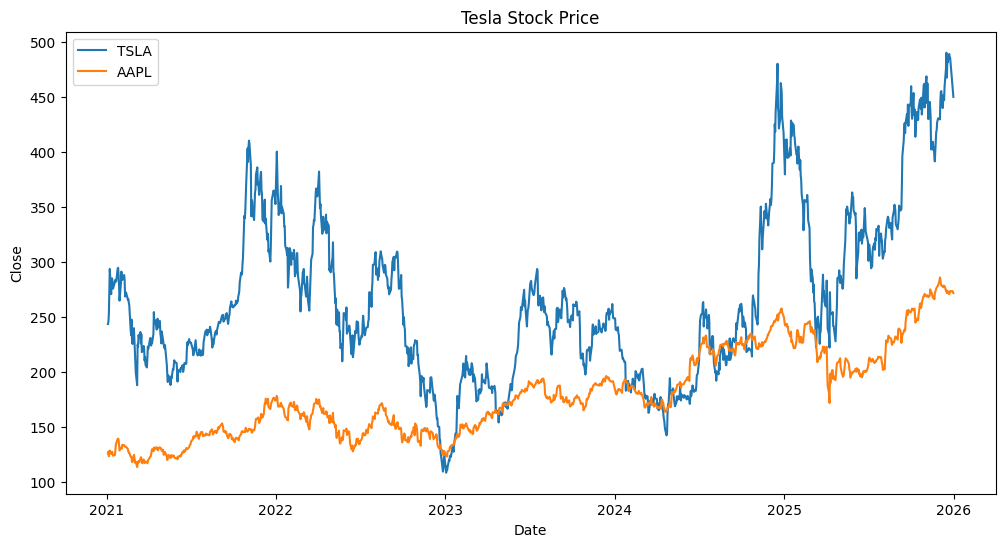

In [8]:
# adjusting figure size
pyplot.rcParams['figure.figsize'] = (12, 6)

# plotting TSLA close throughout the timeline
pyplot.plot(tesla_df['Close'], label = 'TSLA')
pyplot.plot(aapl_df['Close'], label = 'AAPL')

# labeling x axis, y axis and naming chart
pyplot.xlabel('Date')
pyplot.ylabel('Close')
pyplot.title('Tesla Stock Price')
pyplot.legend()
pyplot.show()

In [9]:
# Saving stock info to temp file, could save to google drive by connecting google drive
tesla_df.to_csv('tesla_df.csv')
aapl_df.to_csv('aapl_df.csv')

In [10]:
# week intervals throuhgout the year
week_intervals = (4, 16, 28, 40, 52)

In [11]:
# defining a function for calculating moving averages
def calculate_moving_averages(data, feature):
  # copying data so we don't change the original data
  stock_data = data.copy()

  # for loop to calculate mean in week intervals
  for interval in week_intervals:
    moving_average_column = f'{interval}_week_moving_average'
    stock_data[moving_average_column] = stock_data[feature].rolling(window = interval * 7, min_periods = 1).mean()

  # return stock data
  return stock_data

In [12]:
# calculate moving averages for tesla and apple
tesla_df = calculate_moving_averages(tesla_df, 'Close')
aapl_df = calculate_moving_averages(aapl_df, 'Close')

In [13]:
tesla_df

Price,Close,High,Low,Open,Volume,4_week_moving_average,16_week_moving_average,28_week_moving_average,40_week_moving_average,52_week_moving_average
Ticker,TSLA,TSLA,TSLA,TSLA,TSLA,,,,,
Date,,,,,,,,,,
2021-01-04,243.256668,248.163330,239.063339,239.820007,145914600,243.256668,243.256668,243.256668,243.256668,243.256668
2021-01-05,245.036667,246.946671,239.733337,241.220001,96735600,244.146667,244.146667,244.146667,244.146667,244.146667
2021-01-06,251.993332,258.000000,249.699997,252.830002,134100000,246.762222,246.762222,246.762222,246.762222,246.762222
2021-01-07,272.013336,272.329987,258.399994,259.209991,154496700,253.075001,253.075001,253.075001,253.075001,253.075001
2021-01-08,293.339996,294.829987,279.463318,285.333344,225166500,261.128000,261.128000,261.128000,261.128000,261.128000
...,...,...,...,...,...,...,...,...,...,...
2025-12-24,485.399994,490.899994,476.799988,488.480011,41285400,443.327502,401.940446,357.084082,358.940607,330.029918
2025-12-26,475.190002,489.089996,473.820007,485.230011,58780700,445.857501,403.239911,358.358980,359.464536,330.630550


In [14]:
aapl_df

Price,Close,High,Low,Open,Volume,4_week_moving_average,16_week_moving_average,28_week_moving_average,40_week_moving_average,52_week_moving_average
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL,,,,,
Date,,,,,,,,,,
2021-01-04,125.740822,129.821736,123.165956,129.734291,143301900,125.740822,125.740822,125.740822,125.740822,125.740822
2021-01-05,127.295479,128.004792,124.788628,125.235592,97664900,126.518150,126.518150,126.518150,126.518150,126.518150
2021-01-06,123.010529,127.334363,122.796765,124.098776,155088000,125.348943,125.348943,125.348943,125.348943,125.348943
2021-01-07,127.208046,127.897922,124.234808,124.720632,109578200,125.813719,125.813719,125.813719,125.813719,125.813719
2021-01-08,128.306015,128.869572,126.537610,128.675231,105158200,126.312178,126.312178,126.312178,126.312178,126.312178
...,...,...,...,...,...,...,...,...,...,...
2025-12-24,273.302216,274.919206,271.695216,271.834940,17910600,274.830104,249.518861,230.128891,231.847961,229.832784
2025-12-26,272.893005,274.859353,272.353998,273.651606,21521800,274.865396,250.077321,230.441753,232.026841,229.942920


<B> Visualing Moving Average of Stocks </B>

Text(0.5, 1.0, 'Tesla Closing Price Moving Average')

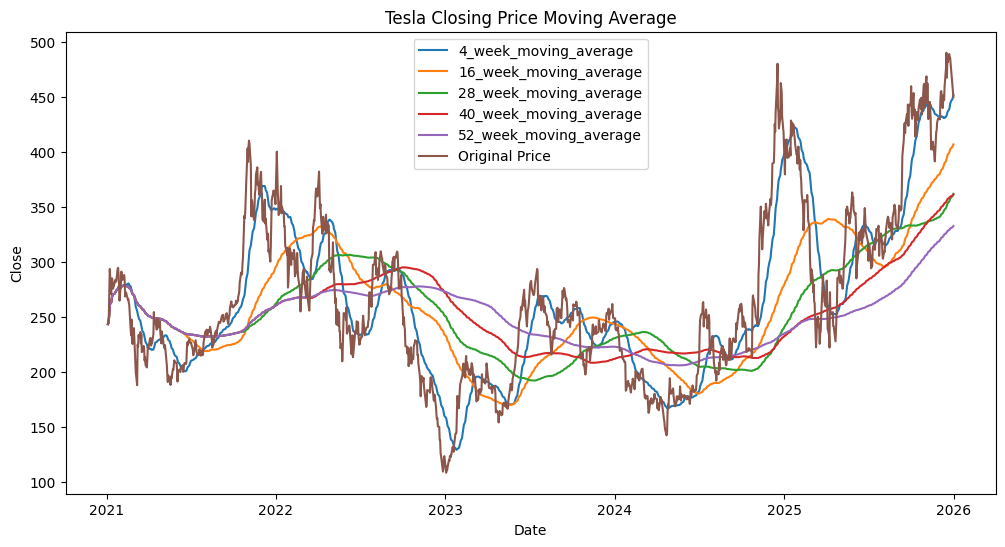

In [15]:
# week intervals on one chart with labels.
for interval in week_intervals:
  moving_average_column = f'{interval}_week_moving_average'
  pyplot.plot(tesla_df[moving_average_column], label = f'{interval}_week_moving_average')

# ploting original price for comparison.
pyplot.plot(tesla_df.index ,tesla_df['Close'], label = 'Original Price')
pyplot.legend()
pyplot.xlabel('Date')
pyplot.ylabel('Close')
pyplot.title('Tesla Closing Price Moving Average')
# if you want seperate charts for each week inteveral uncomment pyplot.show()
# pyplot.show()

Text(0.5, 1.0, 'Apple Closing Price Moving Average')

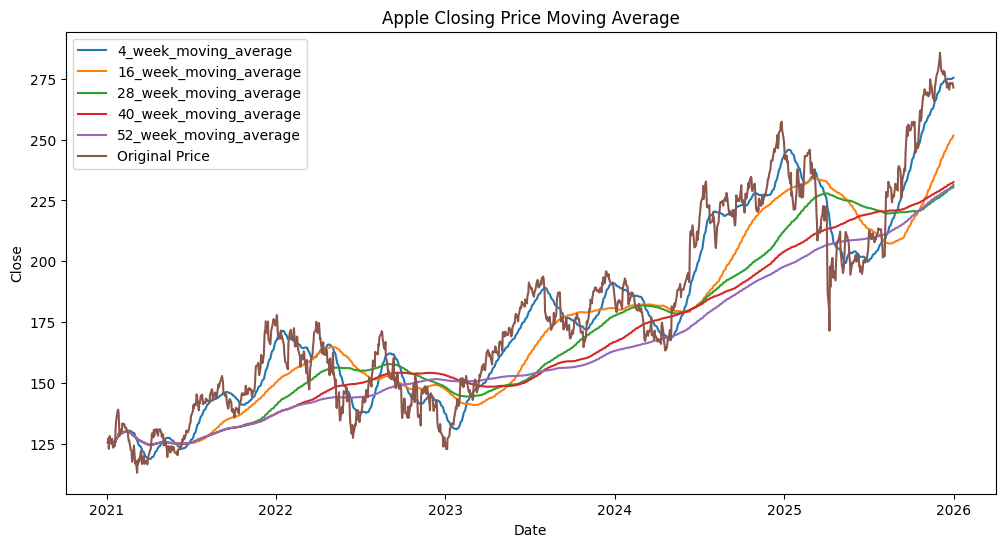

In [16]:
# week intervals on one chart with labels.
for interval in week_intervals:
  moving_average_column = f'{interval}_week_moving_average'
  pyplot.plot(aapl_df[moving_average_column], label = f'{interval}_week_moving_average')

# ploting original price for comparison.
pyplot.plot(aapl_df.index ,aapl_df['Close'], label = 'Original Price')
pyplot.legend()
pyplot.xlabel('Date')
pyplot.ylabel('Close')
pyplot.title('Apple Closing Price Moving Average')
# if you want seperate charts for each week inteveral uncomment pyplot.show()
# pyplot.show()